# Binary Classification: Synthetic vs Original Mammograms

This notebook trains and evaluates classifiers to distinguish between GAN-generated synthetic mammograms and real mammograms.

## Experiments

**Experiment 1: Baseline Classifier (Raw Data)**
- Uses images as-is without normalization
- Tests how easily distinguishable they are due to technical differences
- Expected: Higher accuracy due to brightness/contrast differences

**Experiment 2: Normalized Classifier (Fair GAN Quality Test)**
- Per-image normalization to remove brightness bias
- Data augmentation (brightness, contrast, flips)
- True test of GAN quality based on texture and structure
- Expected: Lower accuracy if GAN is realistic

## Dataset
- Synthetic images: 99,999 (512x512)
- Original images: 163,568 (512x512)
- Balanced sampling: 99,999 from each class
- Split: 80% train, 10% validation, 10% test


## Setup and Imports


In [1]:
import os
import sys
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import cv2
import time

import tensorflow as tf
from tensorflow import keras

# Add current directory to Python path to import classifier module
notebook_dir = '/home/a.kanamarlapudi001/projects/omama-proj/_EXPERIMENTS/SYNTHETIC/Avanith'
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

# Import our custom classifier module
import classifier

# Reload module if making changes
import importlib
importlib.reload(classifier)

# Set random seeds for reproducibility
classifier.set_seed(42)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU available: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  {gpu}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU")

print(f"TensorFlow version: {tf.__version__}")


2025-10-25 10:26:14.107518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761402374.124510 3834611 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761402374.129703 3834611 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761402374.141967 3834611 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761402374.141982 3834611 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761402374.141984 3834611 computation_placer.cc:177] computation placer alr

GPU available: 1 device(s)
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth enabled
TensorFlow version: 2.19.0


## Configuration and Paths


In [ ]:
# Dataset paths
SYNTHETIC_PATH = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/full_synthetic_resized/'
ORIGINAL_PATH = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/full_original_method3/'

# Output paths (all in scratch folder)
OUTPUT_BASE = '/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/'
SPLITS_DIR = os.path.join(OUTPUT_BASE, 'splits')
MODELS_DIR_BASELINE = os.path.join(OUTPUT_BASE, 'experiment1_baseline', 'models')
RESULTS_DIR_BASELINE = os.path.join(OUTPUT_BASE, 'experiment1_baseline', 'results')
MODELS_DIR_NORMALIZED = os.path.join(OUTPUT_BASE, 'experiment2_normalized', 'models')
RESULTS_DIR_NORMALIZED = os.path.join(OUTPUT_BASE, 'experiment2_normalized', 'results')
LOGS_DIR = os.path.join(OUTPUT_BASE, 'logs')

# Create directories
for directory in [SPLITS_DIR, MODELS_DIR_BASELINE, RESULTS_DIR_BASELINE,
                  MODELS_DIR_NORMALIZED, RESULTS_DIR_NORMALIZED, LOGS_DIR]:
    os.makedirs(directory, exist_ok=True)

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 50
EARLY_STOP_PATIENCE = 10
LR_PATIENCE = 5

# Dataset split ratios
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1

# Number of images to sample from each class
NUM_SAMPLES_PER_CLASS = 99999

print("Configuration loaded successfully")
print(f"Output base directory: {OUTPUT_BASE}")


Configuration loaded successfully
Output base directory: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/


## Data Loading and Splitting


In [3]:
def load_and_split_data():
    """
    Load image paths and create train/val/test splits.
    If splits already exist, load them. Otherwise, create and save new splits.
    
    Returns:
        dict: Dictionary containing train/val/test splits for both classes
    """
    # Check if splits already exist
    split_files = {
        'train_synthetic': os.path.join(SPLITS_DIR, 'train_synthetic.txt'),
        'train_original': os.path.join(SPLITS_DIR, 'train_original.txt'),
        'val_synthetic': os.path.join(SPLITS_DIR, 'val_synthetic.txt'),
        'val_original': os.path.join(SPLITS_DIR, 'val_original.txt'),
        'test_synthetic': os.path.join(SPLITS_DIR, 'test_synthetic.txt'),
        'test_original': os.path.join(SPLITS_DIR, 'test_original.txt')
    }
    
    # Check if all split files exist
    all_exist = all(os.path.exists(f) for f in split_files.values())
    
    if all_exist:
        print("Loading existing splits from files...")
        splits = {}
        for key, filepath in split_files.items():
            with open(filepath, 'r') as f:
                splits[key] = [line.strip() for line in f.readlines()]
        print("Loaded existing splits successfully")
    else:
        print("Creating new splits...")
        
        # Load all image paths
        synthetic_files = sorted(glob.glob(os.path.join(SYNTHETIC_PATH, '*.png')))
        original_files = sorted(glob.glob(os.path.join(ORIGINAL_PATH, '*.png')))
        
        print(f"Total synthetic images: {len(synthetic_files)}")
        print(f"Total original images: {len(original_files)}")
        
        # Balance dataset by sampling NUM_SAMPLES_PER_CLASS from each
        if len(synthetic_files) > NUM_SAMPLES_PER_CLASS:
            synthetic_files = random.sample(synthetic_files, NUM_SAMPLES_PER_CLASS)
        if len(original_files) > NUM_SAMPLES_PER_CLASS:
            original_files = random.sample(original_files, NUM_SAMPLES_PER_CLASS)
        
        print(f"Sampled {len(synthetic_files)} synthetic images")
        print(f"Sampled {len(original_files)} original images")
        
        # Shuffle
        random.shuffle(synthetic_files)
        random.shuffle(original_files)
        
        # Calculate split sizes
        n_syn = len(synthetic_files)
        n_orig = len(original_files)
        
        train_syn = int(n_syn * TRAIN_RATIO)
        val_syn = int(n_syn * VAL_RATIO)
        
        train_orig = int(n_orig * TRAIN_RATIO)
        val_orig = int(n_orig * VAL_RATIO)
        
        # Create splits
        splits = {
            'train_synthetic': synthetic_files[:train_syn],
            'val_synthetic': synthetic_files[train_syn:train_syn+val_syn],
            'test_synthetic': synthetic_files[train_syn+val_syn:],
            'train_original': original_files[:train_orig],
            'val_original': original_files[train_orig:train_orig+val_orig],
            'test_original': original_files[train_orig+val_orig:]
        }
        
        # Save splits to files
        for key, files in splits.items():
            filepath = split_files[key]
            with open(filepath, 'w') as f:
                for file in files:
                    f.write(file + '\\n')
        
        print("Created and saved new splits")
    
    # Print split statistics
    print("\\n" + "="*70)
    print("SPLIT STATISTICS")
    print("="*70)
    print(f"Training:   {len(splits['train_synthetic'])} synthetic + {len(splits['train_original'])} original = {len(splits['train_synthetic']) + len(splits['train_original'])} total")
    print(f"Validation: {len(splits['val_synthetic'])} synthetic + {len(splits['val_original'])} original = {len(splits['val_synthetic']) + len(splits['val_original'])} total")
    print(f"Test:       {len(splits['test_synthetic'])} synthetic + {len(splits['test_original'])} original = {len(splits['test_synthetic']) + len(splits['test_original'])} total")
    print("="*70)
    
    return splits

# Load or create splits
splits = load_and_split_data()


Creating new splits...
Total synthetic images: 99999
Total original images: 163568
Sampled 99999 synthetic images
Sampled 99999 original images
Created and saved new splits
\n======================================================================
SPLIT STATISTICS
Training:   79999 synthetic + 79999 original = 159998 total
Validation: 9999 synthetic + 9999 original = 19998 total
Test:       10001 synthetic + 10001 original = 20002 total


## Import Classifier Module and Display Model Architecture


In [4]:
# Create model instance to show architecture
model = classifier.build_custom_cnn()

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("="*70)
print("CUSTOM CNN ARCHITECTURE")
print("="*70)
model.summary()
print("="*70)

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")
print(f"Model size: {total_params * 4 / 1024 / 1024:.2f} MB (assuming float32)")
print("="*70)


I0000 00:00:1761402378.590934 3834611 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38380 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:b7:00.0, compute capability: 8.0


CUSTOM CNN ARCHITECTURE


Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 512, 512, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 512, 512, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 512, 512, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 512, 512, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 256, 256, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256, 256, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 128, 128, 128)  │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 64, 64, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 32, 32, 512)    │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu5 (Activation)              │ (None, 32, 32, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,736,450 (6.62 MB)

 Trainable params: 1,734,466 (6.62 MB)

 Non-trainable params: 1,984 (7.75 KB)


Total parameters: 1,736,450
Model size: 6.62 MB (assuming float32)


## Experiment 1: Baseline Classifier (Raw Data)

This experiment trains a classifier on raw images (scaled to [0,1]) without normalization.
Tests how easily distinguishable the images are due to technical differences like brightness.


In [5]:
# Create baseline data generators
train_gen_baseline = classifier.BaselineDataGenerator(
    splits['train_synthetic'], splits['train_original'], 
    batch_size=BATCH_SIZE, shuffle=True
)

val_gen_baseline = classifier.BaselineDataGenerator(
    splits['val_synthetic'], splits['val_original'], 
    batch_size=BATCH_SIZE, shuffle=False
)

test_gen_baseline = classifier.BaselineDataGenerator(
    splits['test_synthetic'], splits['test_original'], 
    batch_size=BATCH_SIZE, shuffle=False
)

print("Baseline data generators created")
print(f"Train batches: {len(train_gen_baseline)}")
print(f"Val batches: {len(val_gen_baseline)}")
print(f"Test batches: {len(test_gen_baseline)}")


Baseline data generators created
Train batches: 5000
Val batches: 625
Test batches: 626


In [6]:
# Build and compile model for Experiment 1
model_baseline = classifier.build_custom_cnn()

model_baseline.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_baseline, best_model_path_baseline = classifier.train_model(
    model=model_baseline,
    train_generator=train_gen_baseline,
    val_generator=val_gen_baseline,
    num_epochs=NUM_EPOCHS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    lr_patience=LR_PATIENCE,
    save_dir=MODELS_DIR_BASELINE,
    experiment_name="Experiment 1: Baseline (Raw Data)"
)



Starting training for Experiment 1: Baseline (Raw Data)...
Number of epochs: 50
Early stopping patience: 10


/home/a.kanamarlapudi001/miniconda3/envs/tf_gpu_env/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1761402382.259249 3834775 service.cc:152] XLA service 0x7f5a98003760 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1761402382.259282 3834775 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-10-25 10:26:22.362781: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1761402382.793239 3834775 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-10-25 10:26:23.761546: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1506', 228 bytes spill stores, 228 bytes spill loads

2025-10-25 10:26:28.716256: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1506'

   2/5000 ━━━━━━━━━━━━━━━━━━━━ 6:18 76ms/step - accuracy: 0.5781 - loss: 0.6955   

...

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 465s 93ms/step - accuracy: 1.0000 - loss: 9.6136e-06 - val_accuracy: 1.0000 - val_loss: 9.5377e-11 - learning_rate: 2.5000e-04
Epoch 17/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 1.4681e-08
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 17: val_loss improved from 0.00000 to 0.00000, saving model to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment1_baseline/models/best_model.h5


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 431s 86ms/step - accuracy: 1.0000 - loss: 1.4680e-08 - val_accuracy: 1.0000 - val_loss: 6.5572e-11 - learning_rate: 2.5000e-04
Epoch 18/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 3.5140e-09
Epoch 18: val_loss improved from 0.00000 to 0.00000, saving model to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment1_baseline/models/best_model.h5


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 467s 93ms/step - accuracy: 1.0000 - loss: 3.5145e-09 - val_accuracy: 1.0000 - val_loss: 2.9805e-11 - learning_rate: 1.2500e-04
Epoch 19/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 1.7332e-04
Epoch 19: val_loss improved from 0.00000 to 0.00000, saving model to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment1_baseline/models/best_model.h5


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 468s 94ms/step - accuracy: 1.0000 - loss: 1.7330e-04 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 1.2500e-04
Epoch 20/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 3.9664e-09
Epoch 20: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 467s 93ms/step - accuracy: 1.0000 - loss: 3.9664e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 1.2500e-04
Epoch 21/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 3.0039e-09
Epoch 21: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 440s 88ms/step - accuracy: 1.0000 - loss: 3.0040e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 1.2500e-04
Epoch 22/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 1.0000 - loss: 4.0755e-06
Epoch 22: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 22: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━

KeyboardInterrupt: 

In [7]:
# Plot training curves for Experiment 1
classifier.plot_training_curves(history_baseline, 
                                save_path=os.path.join(RESULTS_DIR_BASELINE, 'training_curves.png'))


NameError: name 'history_baseline' is not defined

In [8]:
# Load best model and evaluate on test set
model_baseline = keras.models.load_model(best_model_path_baseline)

results_baseline = classifier.evaluate_model(model_baseline, test_gen_baseline)

print("\n" + "="*70)
print("EXPERIMENT 1 (BASELINE) - TEST RESULTS")
print("="*70)
print(f"Accuracy: {results_baseline['accuracy']*100:.2f}%")
print(f"ROC AUC: {results_baseline['auc']:.4f}")
print(f"\nPer-Class Metrics:")
print(f"  Synthetic - Precision: {results_baseline['precision_per_class'][0]:.4f}, Recall: {results_baseline['recall_per_class'][0]:.4f}, F1: {results_baseline['f1_per_class'][0]:.4f}")
print(f"  Original  - Precision: {results_baseline['precision_per_class'][1]:.4f}, Recall: {results_baseline['recall_per_class'][1]:.4f}, F1: {results_baseline['f1_per_class'][1]:.4f}")
print("="*70)

# Save training history
classifier.save_training_history(history_baseline, os.path.join(RESULTS_DIR_BASELINE, 'training_history.csv'))


NameError: name 'best_model_path_baseline' is not defined

In [9]:
# Plot confusion matrix and ROC curve for Experiment 1
classifier.plot_confusion_matrix(results_baseline['confusion_matrix'],
                                save_path=os.path.join(RESULTS_DIR_BASELINE, 'confusion_matrix.png'))

classifier.plot_roc_curve(results_baseline['fpr'], results_baseline['tpr'], results_baseline['auc'],
                         save_path=os.path.join(RESULTS_DIR_BASELINE, 'roc_curve.png'))

# Save metrics report
classifier.save_metrics_report(results_baseline, os.path.join(RESULTS_DIR_BASELINE, 'test_metrics.txt'))


NameError: name 'results_baseline' is not defined

## Experiment 2: Normalized Classifier (Fair GAN Quality Test)

This experiment trains a classifier with per-image normalization and data augmentation.
This is the TRUE test of GAN quality as it removes technical biases and forces the model to learn texture/structure.


In [10]:
# Create normalized data generators (with augmentation for training)
train_gen_normalized = classifier.NormalizedDataGenerator(
    splits['train_synthetic'], splits['train_original'], 
    batch_size=BATCH_SIZE, shuffle=True, augment=True
)

val_gen_normalized = classifier.NormalizedDataGenerator(
    splits['val_synthetic'], splits['val_original'], 
    batch_size=BATCH_SIZE, shuffle=False, augment=False
)

test_gen_normalized = classifier.NormalizedDataGenerator(
    splits['test_synthetic'], splits['test_original'], 
    batch_size=BATCH_SIZE, shuffle=False, augment=False
)

print("Normalized data generators created (with augmentation for training)")
print(f"Train batches: {len(train_gen_normalized)}")
print(f"Val batches: {len(val_gen_normalized)}")
print(f"Test batches: {len(test_gen_normalized)}")


Normalized data generators created (with augmentation for training)
Train batches: 5000
Val batches: 625
Test batches: 626


In [11]:
# Build and compile model for Experiment 2
model_normalized = classifier.build_custom_cnn()

model_normalized.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_normalized, best_model_path_normalized = classifier.train_model(
    model=model_normalized,
    train_generator=train_gen_normalized,
    val_generator=val_gen_normalized,
    num_epochs=NUM_EPOCHS,
    early_stop_patience=EARLY_STOP_PATIENCE,
    lr_patience=LR_PATIENCE,
    save_dir=MODELS_DIR_NORMALIZED,
    experiment_name="Experiment 2: Normalized (Fair GAN Test)"
)



Starting training for Experiment 2: Normalized (Fair GAN Test)...
Number of epochs: 50
Early stopping patience: 10
Epoch 1/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9966 - loss: 0.0115
Epoch 1: val_loss improved from inf to 0.00162, saving model to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/models/best_model.h5


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 636s 126ms/step - accuracy: 0.9966 - loss: 0.0115 - val_accuracy: 0.9995 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 2/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9992 - loss: 0.0036
Epoch 2: val_loss did not improve from 0.00162
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 632s 126ms/step - accuracy: 0.9992 - loss: 0.0036 - val_accuracy: 0.9993 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 3/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9995 - loss: 0.0016
Epoch 3: val_loss did not improve from 0.00162
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 594s 119ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9964 - val_loss: 0.0169 - learning_rate: 0.0010
Epoch 4/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9995 - loss: 0.0027
Epoch 4: val_loss improved from 0.00162 to 0.00023, saving model to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/models/best_model.h5


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 638s 128ms/step - accuracy: 0.9995 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 2.2762e-04 - learning_rate: 0.0010
Epoch 5/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9998 - loss: 9.1657e-04
Epoch 5: val_loss did not improve from 0.00023
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 633s 127ms/step - accuracy: 0.9998 - loss: 9.1662e-04 - val_accuracy: 0.5000 - val_loss: 40.9063 - learning_rate: 0.0010
Epoch 6/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9997 - loss: 0.0021
Epoch 6: val_loss did not improve from 0.00023
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 619s 124ms/step - accuracy: 0.9997 - loss: 0.0021 - val_accuracy: 0.5541 - val_loss: 1.5578 - learning_rate: 0.0010
Epoch 7/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9998 - loss: 0.0011
Epoch 7: val_loss did not improve from 0.00023
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 627s 125ms/step - accuracy: 0.9998 - loss: 0.0011 - val_accuracy: 0.9512 - val_loss: 0.7071 - learning_r

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 639s 128ms/step - accuracy: 0.9997 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 7.5183e-06 - learning_rate: 0.0010
Epoch 9/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9999 - loss: 9.0348e-04
Epoch 9: val_loss improved from 0.00001 to 0.00000, saving model to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/models/best_model.h5


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 595s 119ms/step - accuracy: 0.9999 - loss: 9.0348e-04 - val_accuracy: 1.0000 - val_loss: 2.6199e-06 - learning_rate: 0.0010
Epoch 10/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.9999 - loss: 6.4305e-04
Epoch 10: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 640s 128ms/step - accuracy: 0.9999 - loss: 6.4310e-04 - val_accuracy: 1.0000 - val_loss: 9.9434e-06 - learning_rate: 0.0010
Epoch 11/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9999 - loss: 5.9098e-04
Epoch 11: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 611s 122ms/step - accuracy: 0.9999 - loss: 5.9104e-04 - val_accuracy: 1.0000 - val_loss: 3.3172e-05 - learning_rate: 0.0010
Epoch 12/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.9999 - loss: 2.4441e-04
Epoch 12: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 620s 124ms/step - accuracy: 0.9999 - loss: 2.4445e-04 - val_accuracy: 0.998

...

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 611s 122ms/step - accuracy: 0.9999 - loss: 5.2348e-04 - val_accuracy: 1.0000 - val_loss: 1.1704e-07 - learning_rate: 5.0000e-04
Epoch 16/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 1.0000 - loss: 1.2845e-04
Epoch 16: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 639s 128ms/step - accuracy: 1.0000 - loss: 1.2846e-04 - val_accuracy: 1.0000 - val_loss: 2.1226e-07 - learning_rate: 5.0000e-04
Epoch 17/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 1.0000 - loss: 1.0316e-04
Epoch 17: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 633s 127ms/step - accuracy: 1.0000 - loss: 1.0325e-04 - val_accuracy: 1.0000 - val_loss: 2.5107e-06 - learning_rate: 5.0000e-04
Epoch 18/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.9999 - loss: 4.8028e-04
Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 18: val_loss did not improve from 0.00000
5000/5000 ━━━━━━

5000/5000 ━━━━━━━━━━━━━━━━━━━━ 638s 128ms/step - accuracy: 1.0000 - loss: 9.7120e-05 - val_accuracy: 1.0000 - val_loss: 1.5491e-08 - learning_rate: 2.5000e-04
Epoch 20/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 1.0000 - loss: 4.3795e-07
Epoch 20: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 642s 128ms/step - accuracy: 1.0000 - loss: 4.3791e-07 - val_accuracy: 0.9996 - val_loss: 0.0038 - learning_rate: 2.5000e-04
Epoch 21/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 1.0000 - loss: 8.0404e-05
Epoch 21: val_loss improved from 0.00000 to 0.00000, saving model to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/models/best_model.h5


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 624s 125ms/step - accuracy: 1.0000 - loss: 8.0399e-05 - val_accuracy: 1.0000 - val_loss: 1.1922e-11 - learning_rate: 2.5000e-04
Epoch 22/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 1.0000 - loss: 1.8564e-05
Epoch 22: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 638s 128ms/step - accuracy: 1.0000 - loss: 1.8576e-05 - val_accuracy: 1.0000 - val_loss: 1.0841e-07 - learning_rate: 2.5000e-04
Epoch 23/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 1.0000 - loss: 1.9554e-05
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 23: val_loss improved from 0.00000 to 0.00000, saving model to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/models/best_model.h5


5000/5000 ━━━━━━━━━━━━━━━━━━━━ 610s 122ms/step - accuracy: 1.0000 - loss: 1.9555e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 2.5000e-04
Epoch 24/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 1.0000 - loss: 7.2766e-07
Epoch 24: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 621s 124ms/step - accuracy: 1.0000 - loss: 7.2762e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00 - learning_rate: 1.2500e-04
Epoch 25/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 1.0000 - loss: 1.6923e-06
Epoch 25: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 660s 132ms/step - accuracy: 1.0000 - loss: 1.6941e-06 - val_accuracy: 1.0000 - val_loss: 3.4514e-09 - learning_rate: 1.2500e-04
Epoch 26/50
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 1.0000 - loss: 7.1201e-05
Epoch 26: val_loss did not improve from 0.00000
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 644s 129ms/step - accuracy: 1.0000 - loss: 7.1221e-05 - val_acc


Training complete! Total time: 350.31 minutes
Final model saved to: /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/models/final_model.h5


Training curves saved to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/results/training_curves.png


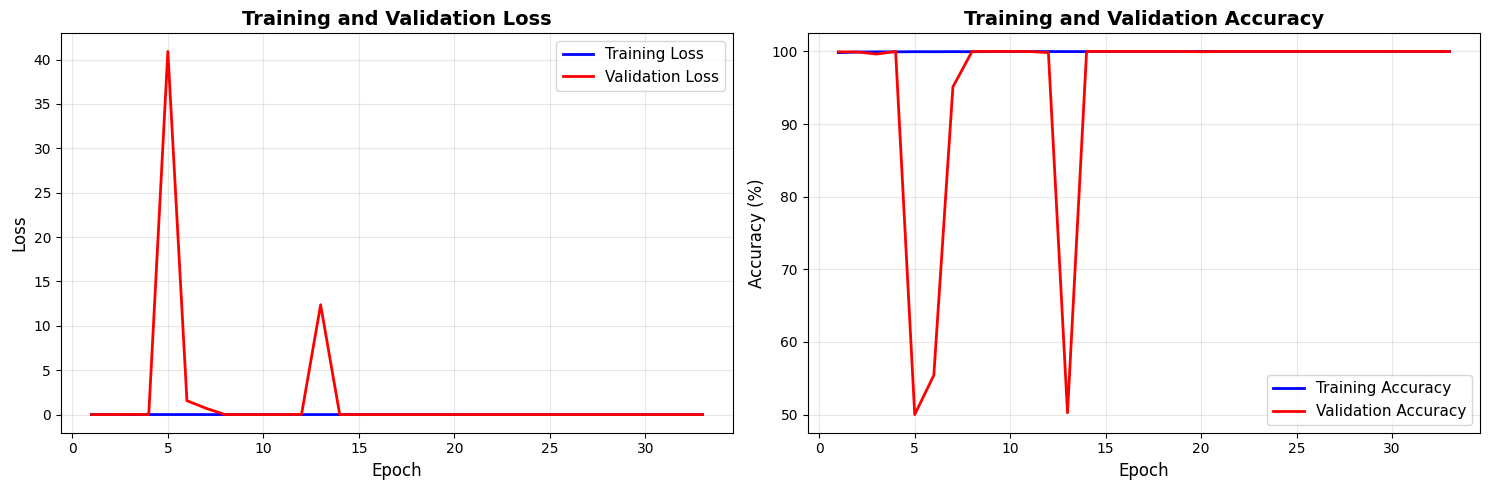

In [12]:
# Plot training curves for Experiment 2
classifier.plot_training_curves(history_normalized, 
                                save_path=os.path.join(RESULTS_DIR_NORMALIZED, 'training_curves.png'))


In [13]:
# Load best model and evaluate on test set
model_normalized = keras.models.load_model(best_model_path_normalized)

results_normalized = classifier.evaluate_model(model_normalized, test_gen_normalized)

print("\n" + "="*70)
print("EXPERIMENT 2 (NORMALIZED) - TEST RESULTS")
print("="*70)
print(f"Accuracy: {results_normalized['accuracy']*100:.2f}%")
print(f"ROC AUC: {results_normalized['auc']:.4f}")
print(f"\nPer-Class Metrics:")
print(f"  Synthetic - Precision: {results_normalized['precision_per_class'][0]:.4f}, Recall: {results_normalized['recall_per_class'][0]:.4f}, F1: {results_normalized['f1_per_class'][0]:.4f}")
print(f"  Original  - Precision: {results_normalized['precision_per_class'][1]:.4f}, Recall: {results_normalized['recall_per_class'][1]:.4f}, F1: {results_normalized['f1_per_class'][1]:.4f}")
print("="*70)

# Save training history
classifier.save_training_history(history_normalized, os.path.join(RESULTS_DIR_NORMALIZED, 'training_history.csv'))


Evaluating on test set...
625/626 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step

2025-10-25 19:58:10.126211: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_181', 128 bytes spill stores, 128 bytes spill loads

2025-10-25 19:58:12.587204: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_181', 8 bytes spill stores, 8 bytes spill loads

2025-10-25 19:58:12.819149: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_181', 16 bytes spill stores, 16 bytes spill loads



626/626 ━━━━━━━━━━━━━━━━━━━━ 80s 126ms/step

EXPERIMENT 2 (NORMALIZED) - TEST RESULTS
Accuracy: 100.00%
ROC AUC: 1.0000

Per-Class Metrics:
  Synthetic - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
  Original  - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
Training history saved to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/results/training_history.csv


Confusion matrix saved to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/results/confusion_matrix.png


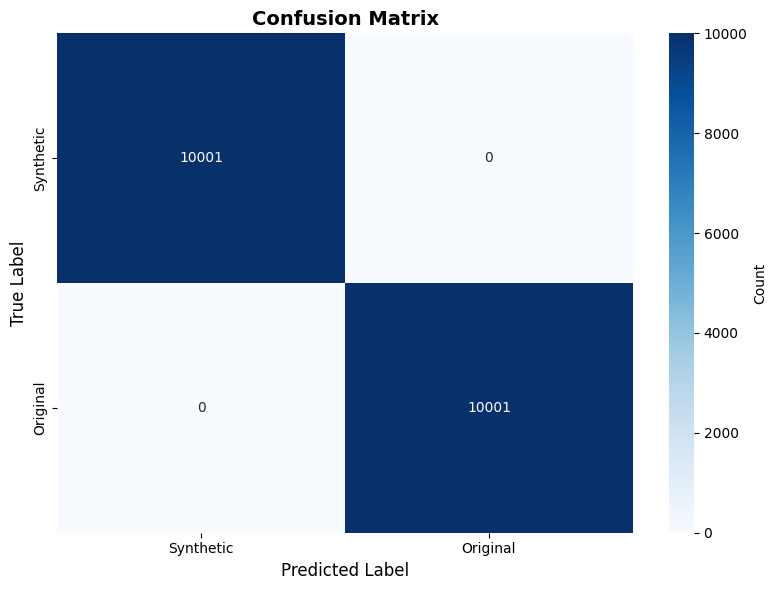

ROC curve saved to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/results/roc_curve.png


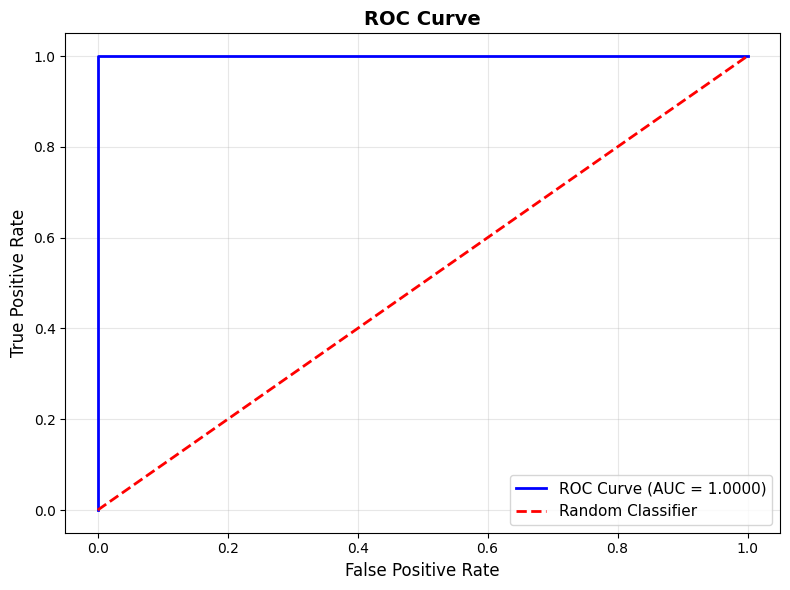

Metrics report saved to /hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/experiment2_normalized/results/test_metrics.txt


In [14]:
# Plot confusion matrix and ROC curve for Experiment 2
classifier.plot_confusion_matrix(results_normalized['confusion_matrix'],
                                save_path=os.path.join(RESULTS_DIR_NORMALIZED, 'confusion_matrix.png'))

classifier.plot_roc_curve(results_normalized['fpr'], results_normalized['tpr'], results_normalized['auc'],
                         save_path=os.path.join(RESULTS_DIR_NORMALIZED, 'roc_curve.png'))

# Save metrics report
classifier.save_metrics_report(results_normalized, os.path.join(RESULTS_DIR_NORMALIZED, 'test_metrics.txt'))


## Final Comparison and Interpretation


In [15]:
# Create comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy (%)', 'ROC AUC', 'Precision (Synthetic)', 'Recall (Synthetic)', 
               'F1-Score (Synthetic)', 'Precision (Original)', 'Recall (Original)', 'F1-Score (Original)'],
    'Experiment 1 (Baseline)': [
        results_baseline['accuracy'] * 100,
        results_baseline['auc'],
        results_baseline['precision_per_class'][0],
        results_baseline['recall_per_class'][0],
        results_baseline['f1_per_class'][0],
        results_baseline['precision_per_class'][1],
        results_baseline['recall_per_class'][1],
        results_baseline['f1_per_class'][1]
    ],
    'Experiment 2 (Normalized)': [
        results_normalized['accuracy'] * 100,
        results_normalized['auc'],
        results_normalized['precision_per_class'][0],
        results_normalized['recall_per_class'][0],
        results_normalized['f1_per_class'][0],
        results_normalized['precision_per_class'][1],
        results_normalized['recall_per_class'][1],
        results_normalized['f1_per_class'][1]
    ]
})

print("\n" + "="*70)
print("EXPERIMENT COMPARISON")
print("="*70)
print(comparison_df.to_string(index=False))
print("="*70)

# Save comparison
comparison_df.to_csv(os.path.join(OUTPUT_BASE, 'experiment_comparison.csv'), index=False)
print(f"\nComparison saved to: {os.path.join(OUTPUT_BASE, 'experiment_comparison.csv')}")


NameError: name 'results_baseline' is not defined

In [ ]:
# Interpretation
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

baseline_acc = results_baseline['accuracy'] * 100
normalized_acc = results_normalized['accuracy'] * 100

print(f"\nExperiment 1 (Baseline - Raw Data): {baseline_acc:.2f}%")
if baseline_acc > 75:
    print("  Interpretation: High accuracy indicates technical differences (brightness/contrast)")
    print("  are easily exploited by the classifier.")
elif baseline_acc > 60:
    print("  Interpretation: Moderate accuracy - some technical differences present.")
else:
    print("  Interpretation: Low accuracy - images are technically similar.")

print(f"\nExperiment 2 (Normalized - Fair Test): {normalized_acc:.2f}%")
if normalized_acc < 60:
    print("  Interpretation: LOW ACCURACY - EXCELLENT GAN QUALITY!")
    print("  The GAN generates highly realistic mammograms that are difficult to")
    print("  distinguish from real images when technical biases are removed.")
elif normalized_acc < 70:
    print("  Interpretation: Moderate accuracy - GOOD GAN quality.")
    print("  The GAN generates realistic images but some learned patterns remain.")
elif normalized_acc < 80:
    print("  Interpretation: Moderate-high accuracy - GAN quality could be improved.")
else:
    print("  Interpretation: High accuracy - GAN quality needs improvement.")
    print("  The classifier can easily distinguish synthetic from real images.")

print("\n" + "="*70)
print("CONCLUSION")
print("="*70)
print("Experiment 2 (Normalized) provides the TRUE measure of GAN quality.")
print("Lower accuracy in Experiment 2 indicates better GAN performance.")
print("="*70)


## Summary

All results have been saved to:
```
/hpcstor6/scratch01/a/a.kanamarlapudi001/synthetic/classifier_results/
```

### Key Files:
- **Data Splits**: `splits/` - Reusable for future experiments
- **Experiment 1**: `experiment1_baseline/` - Models, plots, metrics
- **Experiment 2**: `experiment2_normalized/` - Models, plots, metrics  
- **Comparison**: `experiment_comparison.csv`

### Next Steps:
1. Review the results above
2. Analyze which experiment better represents GAN quality
3. Use these metrics in your research paper
4. If needed, retrain with different hyperparameters using the same splits
